In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

# *** STEP 1: DATA INGESTION ***
base_path = '/content/drive/MyDrive/مشروع تصميم نظم/model_ready_data/'

# Load the training and validation datasets
# X contains the hand landmarks (65 features), Y contains the emergency gesture labels
X_train = np.load(base_path + 'X_train.npy')
y_train = np.load(base_path + 'y_train.npy')
X_val = np.load(base_path + 'X_val.npy')
y_val = np.load(base_path + 'y_val.npy')

# *** STEP 2: LABEL PREPROCESSING ***
# Convert integer labels to One-Hot Encoding format
y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)

# *** STEP 3: DATA NORMALIZATION (SCALING) ***
# Initialize StandardScaler to normalize features (Mean=0, StdDev=1)
# This ensures that different landmark coordinates contribute equally to model learning
scaler = StandardScaler()

# Reshape data to 2D for the Scaler (since it expects [samples * time_steps, features])
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
# Fit the scaler on training data AND transform it
X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(X_train.shape[0], 1, X_train.shape[1])
# Transform validation data using the SAME scaler parameters (mean/std) from training
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_val_scaled = scaler.transform(X_val_reshaped).reshape(X_val.shape[0], 1, X_val.shape[1])
# Final output to verify data dimensions before training
print(f" Training Shape: {X_train_scaled.shape}")
print(f" Validation Shape: {X_val_scaled.shape}")

 Training Shape: (55356, 1, 65)
 Validation Shape: (2306, 1, 65)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# *** STEP 4: MODEL ARCHITECTURE DEFINITION ***
model_final = Sequential([
    # Define input shape: (Time_Steps, Features)
    Input(shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),

    # First Bidirectional LSTM layer: Captures temporal patterns in both forward and backward directions
    # 128 units to provide high capacity for complex gesture recognition
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),# Stabilizes learning and speeds up convergence
    Dropout(0.2),# Prevents overfitting by randomly deactivating 20% of neurons

    # Second Bidirectional LSTM layer: Further refines the extracted temporal features
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.2),

    # Fully Connected (Dense) layers: Decision-making layers for classification
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),

    # Output layer: 10 neurons representing 10 emergency gestures
    # Softmax provides a probability distribution for each class
    Dense(10, activation='softmax')
])

# *** STEP 5: MODEL COMPILATION ***
# Adam optimizer is used for its efficient adaptive learning rate
# Categorical Cross-Entropy is the standard loss for multi-class classification
model_final.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# *** STEP 6: TRAINING CONFIGURATION (CALLBACKS) ***
callbacks = [
    # EarlyStopping: Stops training if validation accuracy doesn't improve for 15 epochs
    # This prevents the model from wasting time and overfitting
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    # ReduceLROnPlateau: Automatically reduces the learning rate when loss plateaus
    # This helps the model "fine-tune" its weights to find the global minimum loss
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]
# *** STEP 7: MODEL TRAINING ***
# Train on a large batch size (128) for stable gradient updates given the 55k samples

history = model_final.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100,
    batch_size=128,
    callbacks=callbacks
)

Epoch 1/100
433/433 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6651 - loss: 0.9392 - val_accuracy: 0.8339 - val_loss: 0.5176 - learning_rate: 0.0010
Epoch 2/100
433/433 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8203 - loss: 0.4996 - val_accuracy: 0.9081 - val_loss: 0.2665 - learning_rate: 0.0010
Epoch 3/100
433/433 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8640 - loss: 0.3805 - val_accuracy: 0.9384 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 4/100
433/433 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.8892 - loss: 0.3109 - val_accuracy: 0.9449 - val_loss: 0.1658 - learning_rate: 0.0010
Epoch 5/100
433/433 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9021 - loss: 0.2726 - val_accuracy: 0.9558 - val_loss: 0.1420 - learning_rate: 0.0010
Epoch 6/100
433/433 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9140 - loss: 0.2430 - val_accuracy: 0.9536 - val_loss: 0.1300 - learning_rate: 0.0010
Epoch 7/100
433/433 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.921

In [15]:
# *** STEP 8: FINAL MODEL EVALUATION (THE TEST) ***

# 1. Load the ultimate Test Set
# These are samples the model has NEVER seen or interacted with during training
X_test = np.load(base_path + 'X_test.npy')
y_test = np.load(base_path + 'y_test.npy')

# 2. Categorical Conversion
# Prepare ground truth labels in the same format as the model's output (One-Hot)
y_test_cat = to_categorical(y_test)

# 3. Data Transformation & Re-scaling
# Crucial: We use ONLY .transform() here, not .fit().
# This ensures we use the exact same mean and standard deviation from the training data.
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape[0], 1, X_test.shape[1])

# 4. Final Performance Assessment
print("Evaluating the model on the final unseen test set")
test_loss, test_accuracy = model_final.evaluate(X_test_scaled, y_test_cat)

print("\n" + "="*40)
print(f"FINAL TEST ACCURACY: {test_accuracy * 100:.2f}%")
print(f"FINAL TEST LOSS: {test_loss:.4f}")
print("="*40)

Evaluating the model on the final unseen test set
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9857 - loss: 0.0490

FINAL TEST ACCURACY: 98.57%
FINAL TEST LOSS: 0.0490


73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


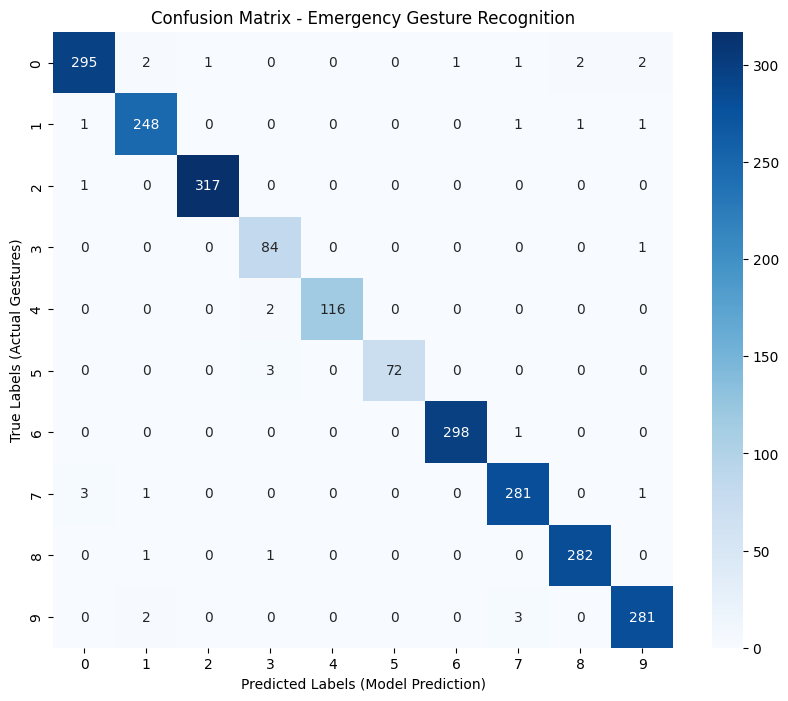

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       304
           1       0.98      0.98      0.98       252
           2       1.00      1.00      1.00       318
           3       0.93      0.99      0.96        85
           4       1.00      0.98      0.99       118
           5       1.00      0.96      0.98        75
           6       1.00      1.00      1.00       299
           7       0.98      0.98      0.98       286
           8       0.99      0.99      0.99       284
           9       0.98      0.98      0.98       286

    accuracy                           0.99      2307
   macro avg       0.98      0.98      0.98      2307
weighted avg       0.99      0.99      0.99      2307



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# *** STEP 9: VISUALIZING MODEL (CONFUSION MATRIX) ***

# 1. Generate model predictions for the unseen test set
# y_pred returns probability distributions for each sample
y_pred = model_final.predict(X_test_scaled)

# Convert probabilities to discrete class indices using argmax
y_pred_classes = np.argmax(y_pred, axis=1)

# Extract true class indices from the one-hot encoded ground truth
y_true = np.argmax(y_test_cat, axis=1)

# 2. Compute the Confusion Matrix
# This table compares the Actual classes vs. the Predicted classes
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Plotting the Heatmap for better visualization
plt.figure(figsize=(10, 8))
# 'annot=True' displays the number of samples in each cell
# 'fmt=d' ensures numbers are shown as integers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Emergency Gesture Recognition')
plt.ylabel('True Labels (Actual Gestures)')
plt.xlabel('Predicted Labels (Model Prediction)')
plt.show()

# 4. Detailed Statistical Report
# Generates Precision, Recall, and F1-Score for each of the 10 gesture classes
# This is vital for identifying which specific gestures the model might struggle with
print("Detailed Classification Report:")
print(classification_report(y_true, y_pred_classes))

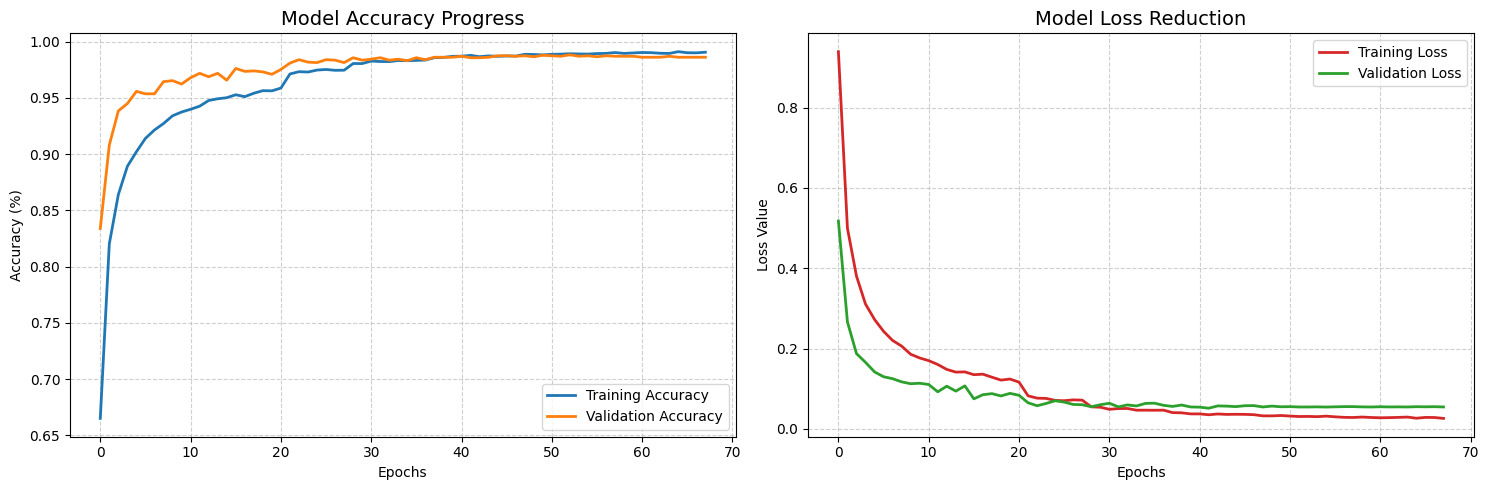

In [18]:
import matplotlib.pyplot as plt

# Initialize the plotting area with two subplots side-by-side
plt.figure(figsize=(15, 5))

# *** SUBPLOT 1: ACCURACY CURVE ***
plt.subplot(1, 2, 1)
# Plot training and validation accuracy to monitor learning progress
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)

# Add chart metadata for clarity
plt.title('Model Accuracy Progress', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6) # Add grid for better readability

# *** SUBPLOT 2: LOSS CURVE ***
plt.subplot(1, 2, 2)
# Plot training and validation loss to monitor error reduction
plt.plot(history.history['loss'], label='Training Loss', color='#d62728', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#2ca02c', linewidth=2)

# Add chart metadata for clarity
plt.title('Model Loss Reduction', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Finalize the layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

In [21]:
# Save the trained model to a file
model_final.save('Emergency_Model_Final.h5')
print("Model saved successfully as Emergency_Model_Final.h5")

Model saved successfully as Emergency_Model_Final.h5
